# Clusterização de municípios brasileiros por perfil socioeconômico

Notebook passo a passo aplicando as técnicas da **Aula 4 — Técnicas para Reconhecimento de Padrões** (Prof. Dr. Erick G. S. Nascimento) ao dataset `dados_municipais_completos.csv` (5.571 municípios × 39 variáveis, construído nas etapas anteriores).

Roteiro, seguindo a apresentação e o Trabalho proposto:
1. Carga e seleção de variáveis
2. Análise exploratória e padronização
3. Escolha do número de clusters pela **inércia** (método do cotovelo)
4. **K-means** (scikit-learn, inicialização k-means++)
5. Implementação própria do k-means com distâncias **Euclidiana** e de **Mahalanobis**
6. **Agrupamento aglomerativo hierárquico** (vínculos simples, completo e médio + dendrograma)
7. **DBSCAN**
8. **Fuzzy C-means**
9. Comparação dos resultados e perfil dos grupos

In [1]:
!pip install -q kneed scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.8 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Carga dos dados e seleção de variáveis

Usamos as variáveis de 2022+ como inputs, evitando duplicar informação (ex.: mantemos a renda de 2022 e descartamos a de 2010; o IDHM fica reservado para validação externa). Variáveis de escala (população, PIB, densidade) entram em log pela forte assimetria.

In [3]:
import pandas as pd
import numpy as np

data = pd.read_csv("/content/drive/MyDrive/Trabalho2AM/dados/dados_municipais_completos.csv")
print(data.shape)
data.head(3)

(5571, 42)


,codigo_ibge,municipio,uf,regiao,populacao_2022,area_km2,densidade_hab_km2,idade_mediana,indice_envelhecimento,pct_pop_urbana,...,mortalidade_infantil_2010,tx_analfabetismo_2010,pct_pobres_2010,fam_bolsa_familia,fam_cadunico,pct_pop_bolsa_familia,fam_cadunico_por_100hab,ideb_anos_finais,ideb_anos_iniciais,todos (1-4)
0,1100015,Alta Floresta D'Oeste,RO,N,21494.0,7067.127,3.04,34.0,44.61,60.35,...,23.8,11.99,26.04,1480,4950,21.089606,23.029683,4.7,5.3,4.5
1,1100023,Ariquemes,RO,N,96833.0,4426.571,21.88,32.0,34.61,86.70,...,19.2,7.90,11.54,7697,22120,21.262379,22.843452,4.8,5.4,4.2
2,1100031,Cabixi,RO,N,5351.0,1314.352,4.07,38.0,64.14,53.19,...,24.8,13.63,21.20,340,1296,19.304802,24.219772,5.0,5.8,4.1


In [4]:
# Variáveis selecionadas para a clusterização
VARIAVEIS = [
    "log_populacao", "log_densidade", "pct_pop_urbana",          # porte e urbanização
    "idade_mediana", "indice_envelhecimento",                     # estrutura etária
    "tx_alfabetizacao_15mais",                                    # educação
    "pct_dom_agua_rede", "pct_dom_esgoto_rede", "pct_dom_lixo_coletado",  # saneamento
    "renda_dom_pc_2022", "pct_pop_ate_meio_sm_2022",              # renda e pobreza
    "log_pib_per_capita",                                         # economia
    "share_vab_agropecuaria", "share_vab_adm_publica",            # estrutura produtiva
    "tmi_2022_2024",                                              # saúde
    "pct_pop_bolsa_familia",                                      # vulnerabilidade
]

df = data.copy()
df["log_populacao"] = np.log10(df["populacao_2022"])
df["log_densidade"] = np.log10(df["densidade_hab_km2"])
df["log_pib_per_capita"] = np.log10(df["pib_per_capita"])

# Remove os poucos municípios com dados faltantes nas variáveis do modelo
df = df.dropna(subset=VARIAVEIS).reset_index(drop=True)
X = df[VARIAVEIS]
print("Base para clusterização:", X.shape)
X.describe().T[["mean", "std", "min", "max"]].round(2)

Base para clusterização: (5570, 16)


,mean,std,min,max
log_populacao,4.10,0.51,2.92,7.06
log_densidade,1.41,0.63,-0.82,4.13
pct_pop_urbana,69.04,20.14,7.33,100.00
idade_mediana,35.41,4.51,15.00,53.00
indice_envelhecimento,64.86,28.48,5.40,277.14
tx_alfabetizacao_15mais,88.20,7.56,63.19,99.10
pct_dom_agua_rede,71.72,19.60,0.00,100.00
pct_dom_esgoto_rede,37.72,33.00,0.00,99.95
pct_dom_lixo_coletado,80.24,17.43,1.68,100.00
renda_dom_pc_2022,1211.59,493.34,288.65,4299.91


## 2. Análise exploratória

Pairplot de um subconjunto de variáveis (amostra de 800 municípios para legibilidade) e matriz de correlação.

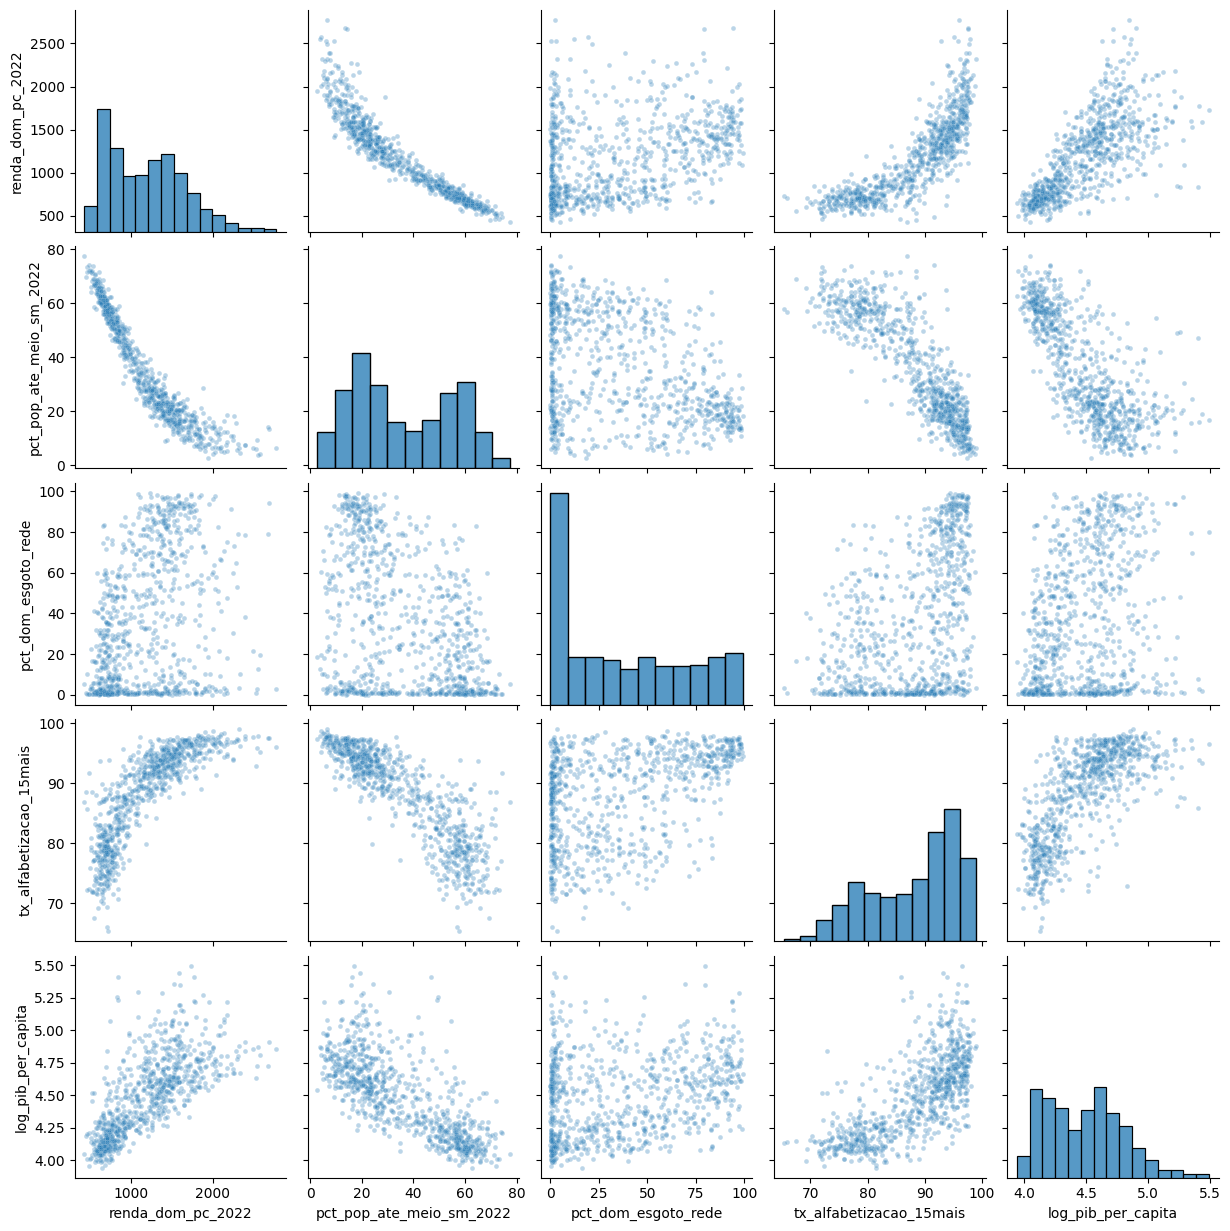

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(df.sample(800, random_state=42),
             vars=["renda_dom_pc_2022", "pct_pop_ate_meio_sm_2022",
                   "pct_dom_esgoto_rede", "tx_alfabetizacao_15mais", "log_pib_per_capita"],
             plot_kws={"alpha": 0.3, "s": 12})
plt.show()

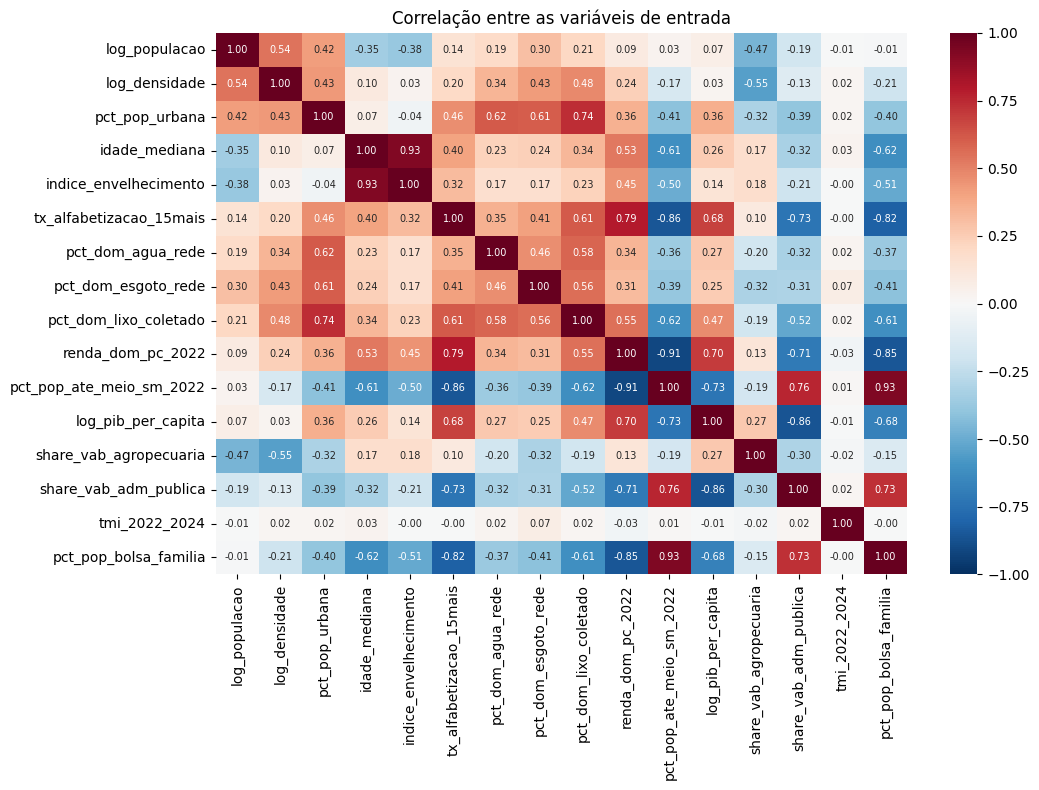

In [6]:
plt.figure(figsize=(11, 8))
sns.heatmap(X.corr(), cmap="RdBu_r", vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 7})
plt.title("Correlação entre as variáveis de entrada")
plt.tight_layout(); plt.show()

## 3. Padronização

Como visto na aula, a **escolha da métrica de distância é extremamente importante**: a distância Euclidiana é sensível à escala das variáveis, então padronizamos tudo para média 0 e desvio 1 (z-score).

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)
X_normalized

array([[ 0.45035966, -1.46807012, -0.43151927, ..., -0.29819437,
        -0.10830707, -0.54519778],
       [ 1.7214752 , -0.10473951,  0.8771058 , ..., -0.13722691,
         0.96940212, -0.53607032],
       [-0.72387463, -1.26652127, -0.78710772, ..., -0.57770487,
        -1.41480368, -0.63948765],
       ...,
       [-0.92539495, -1.27850473,  0.48675312, ..., -0.4803979 ,
        -0.13734033,  0.34227508],
       [-0.65365035, -1.55771412, -0.41215063, ..., -1.11984341,
        -0.69623054, -0.02222948],
       [ 4.5678415 ,  2.04133909,  1.36281181, ...,  0.88146938,
         0.09565798, -0.82945572]])

## 4. Escolhendo o número de clusters pela inércia

**Inércia** = soma das distâncias ao quadrado de cada ponto ao centro do seu cluster: $\sum_{i=1}^{n}(x_i - C_k)^2$. Menor valor corresponde a clusters mais compactos, e o valor diminui à medida que K aumenta — por isso procuramos o **cotovelo** da curva (`KneeLocator`).

[89120, 60314, 50544, 46798, 43407, 40521, 38747, 37226, 35910]


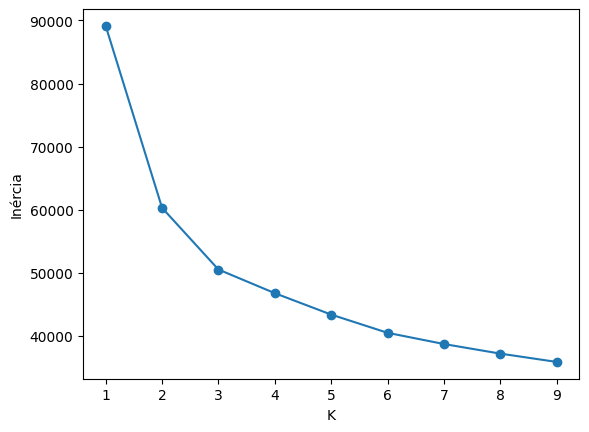

Cotovelo detectado em K = 3


In [8]:
# solução para calcular a qtd de clusters com a inercia
from sklearn.cluster import KMeans
from kneed import KneeLocator

def calculate_wcss(data, k_max=10):
    wcss = []
    for n in range(1, k_max):
        kmeans = KMeans(n_clusters=n, n_init=10, random_state=42)  # inicia várias vezes, pega o melhor
        kmeans.fit(X=data)
        wcss.append(kmeans.inertia_)
    return wcss

def cluster_prev(X):
    wcss = calculate_wcss(X)
    print([round(w) for w in wcss])
    plt.plot(range(1, len(wcss) + 1), wcss, marker="o")
    plt.xlabel("K"); plt.ylabel("Inércia")
    plt.show()
    kn = KneeLocator(range(1, 10), wcss, S=1.0, curve="convex", direction="decreasing")
    return kn.knee

n = cluster_prev(X_normalized)
print("Cotovelo detectado em K =", n)

## 5. K-means (scikit-learn)

O `KMeans` do scikit-learn usa por padrão a **inicialização k-means++** vista na aula: primeiro centro aleatório, próximos escolhidos com probabilidade proporcional a 1/distância², evitando o problema da dependência da designação inicial.

In [9]:
def kmeans_sklearn(X, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, init="k-means++", n_init=10, random_state=42)
    prediction = kmeans.fit_predict(X)
    return kmeans, prediction

print("Kmeans Sklearn")
kmeans, pred_kmeans = kmeans_sklearn(X_normalized, n)
print("Inércia final:", round(kmeans.inertia_, 1))
pd.Series(pred_kmeans).value_counts().sort_index()

Kmeans Sklearn
Inércia final: 50543.9


,count
0,1607
1,2218
2,1745


## 6. Implementação própria: k-means com distância Euclidiana e de Mahalanobis

Item 1 do Trabalho da aula. A **Euclidiana** trata todas as direções igualmente (clusters esféricos); a de **Mahalanobis**, $d(\vec{x},\vec{y}) = \sqrt{(\vec{x}-\vec{y})^T S^{-1} (\vec{x}-\vec{y})}$, leva em conta a covariância dos dados, "esticando" a métrica na direção das correlações (clusters elípticos).

In [10]:
def kmeans_custom(X, n_clusters, metric="euclidean", max_iter=100, seed=42):
    """K-means simples com distância Euclidiana ou de Mahalanobis."""
    rng = np.random.default_rng(seed)
    X = np.asarray(X)
    # matriz S^{-1} para Mahalanobis (identidade recupera a Euclidiana)
    VI = np.linalg.inv(np.cov(X.T)) if metric == "mahalanobis" else np.eye(X.shape[1])

    def dist2(A, b):
        d = A - b
        return np.einsum("ij,jk,ik->i", d, VI, d)  # distância^2 de cada linha de A até b

    # inicialização: k pontos aleatórios distintos
    centros = X[rng.choice(len(X), n_clusters, replace=False)]
    for _ in range(max_iter):
        D = np.column_stack([dist2(X, c) for c in centros])  # (n, k)
        rotulos = D.argmin(axis=1)
        novos = np.array([X[rotulos == k].mean(axis=0) for k in range(n_clusters)])
        if np.allclose(novos, centros):   # pontos não mudam -> convergência
            break
        centros = novos
    inercia = D.min(axis=1).sum()
    return rotulos, centros, inercia

pred_eucl, _, in_eucl = kmeans_custom(X_normalized, n, "euclidean")
pred_maha, _, in_maha = kmeans_custom(X_normalized, n, "mahalanobis")
print(f"Inércia (própria, Euclidiana): {in_eucl:.1f}")
print(f"Tamanhos Euclidiana: {np.bincount(pred_eucl)}")
print(f"Tamanhos Mahalanobis: {np.bincount(pred_maha)}")

Inércia (própria, Euclidiana): 50543.8
Tamanhos Euclidiana: [1588 2217 1765]
Tamanhos Mahalanobis: [1797 1267 2506]


In [11]:
from sklearn.metrics import adjusted_rand_score

print("Concordância (ARI) implementação própria Euclidiana vs sklearn:",
      round(adjusted_rand_score(pred_eucl, pred_kmeans), 3))
print("Concordância (ARI) Mahalanobis vs Euclidiana:",
      round(adjusted_rand_score(pred_maha, pred_eucl), 3))

Concordância (ARI) implementação própria Euclidiana vs sklearn: 0.99
Concordância (ARI) Mahalanobis vs Euclidiana: 0.249


## 7. Agrupamento aglomerativo hierárquico

Cada ponto começa como um cluster; a cada passo mesclamos o par mais próximo, até restar 1 (ou até uma condição de parada: número de clusters desejado ou distância mínima). Comparamos os três **tipos de vínculo** da aula:
- **simples**: distância mínima entre pares de clusters;
- **completo**: distância máxima;
- **médio**: distância média.

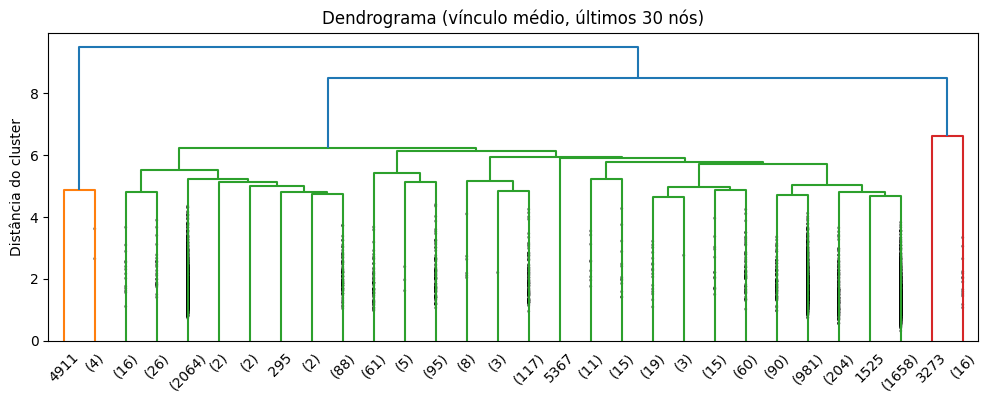

In [12]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z_medio = linkage(X_normalized, method="average")   # vínculo médio
plt.figure(figsize=(12, 4))
dendrogram(Z_medio, truncate_mode="lastp", p=30, show_contracted=True)
plt.title("Dendrograma (vínculo médio, últimos 30 nós)")
plt.ylabel("Distância do cluster")
plt.show()

In [13]:
resultados_hier = {}
for metodo in ["single", "complete", "average"]:
    Z = linkage(X_normalized, method=metodo)
    rot = fcluster(Z, t=n, criterion="maxclust")   # condição de parada: K clusters
    resultados_hier[metodo] = rot
    print(f"vínculo {metodo:9s} -> tamanhos: {np.bincount(rot)[1:]}")

vínculo single    -> tamanhos: [5568    1    1]
vínculo complete  -> tamanhos: [2112  801 2657]
vínculo average   -> tamanhos: [   5 5548   17]


Note o comportamento clássico: o **vínculo simples** sofre encadeamento (um cluster gigante e vários municípios isolados), enquanto completo e médio produzem grupos mais equilibrados.

## 8. DBSCAN

*Density-based spatial clustering of applications with noise.* Parâmetros: **Eps** (raio da vizinhança) e **MinPts** (mínimo de pontos). Rotula os objetos como **Core**, **Border** ou **Noise** — a grande vantagem é detectar outliers (ruído) automaticamente, sem fixar K.

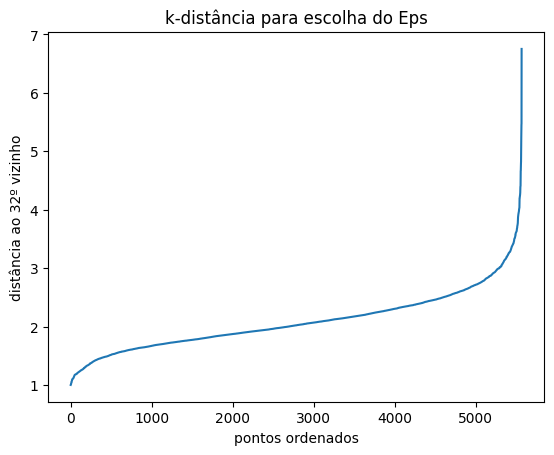

In [14]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

MIN_PTS = 2 * X_normalized.shape[1]   # regra prática: 2 x nº de dimensões

# gráfico da k-distância para escolher Eps (procure o "cotovelo")
viz = NearestNeighbors(n_neighbors=MIN_PTS).fit(X_normalized)
dist, _ = viz.kneighbors(X_normalized)
plt.plot(np.sort(dist[:, -1]))
plt.ylabel(f"distância ao {MIN_PTS}º vizinho"); plt.xlabel("pontos ordenados")
plt.title("k-distância para escolha do Eps")
plt.show()

In [15]:
EPS = 2.0   # ajuste guiado pelo cotovelo do gráfico acima
dbscan = DBSCAN(eps=EPS, min_samples=MIN_PTS)
pred_db = dbscan.fit_predict(X_normalized)

n_clusters_db = len(set(pred_db)) - (1 if -1 in pred_db else 0)
n_ruido = (pred_db == -1).sum()
print(f"clusters: {n_clusters_db} | pontos de ruído (Noise): {n_ruido} ({100*n_ruido/len(pred_db):.1f}%)")
print("Exemplos de municípios rotulados como ruído (outliers):")
df.loc[pred_db == -1, ["municipio", "uf", "populacao_2022"]].nlargest(8, "populacao_2022")

clusters: 1 | pontos de ruído (Noise): 1124 (20.2%)
Exemplos de municípios rotulados como ruído (outliers):


,municipio,uf,populacao_2022
3829,São Paulo,SP,11451999.0
3242,Rio de Janeiro,RJ,6211223.0
5569,Brasília,DF,2817381.0
949,Fortaleza,CE,2428708.0
2162,Salvador,BA,2417678.0
111,Manaus,AM,2063689.0
4931,Porto Alegre,RS,1332845.0
169,Belém,PA,1303403.0


## 9. Fuzzy C-means

No k-means o particionamento é *crisp* (cada ponto pertence a 1 cluster). No **Fuzzy C-means**, cada ponto tem um grau de pertinência a cada cluster; o parâmetro `m` controla o quanto o cluster será *fuzzy* (m=1 vira crisp; valores típicos em torno de 2).

In [16]:
import skfuzzy as fuzz

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_normalized.T, c=n, m=2, error=0.005, maxiter=1000, seed=42)

pred_fuzzy = u.argmax(axis=0)               # cluster de maior pertinência
pertinencia_max = u.max(axis=0)
print("FPC (coeficiente de partição fuzzy, 1 = crisp perfeito):", round(fpc, 3))
print("Pertinência média ao cluster vencedor:", round(pertinencia_max.mean(), 3))

# municípios "de fronteira": baixa pertinência máxima
df.loc[np.argsort(pertinencia_max)[:8], ["municipio", "uf"]].assign(
    pertinencia=np.sort(pertinencia_max)[:8].round(3))

FPC (coeficiente de partição fuzzy, 1 = crisp perfeito): 0.438
Pertinência média ao cluster vencedor: 0.557


,municipio,uf,pertinencia
2508,Engenheiro Caldas,MG,0.339
2036,Jaguarari,BA,0.342
902,Aquiraz,CE,0.342
1925,Coaraci,BA,0.343
1673,Coruripe,AL,0.343
1896,Camacan,BA,0.343
2028,Itororó,BA,0.345
1148,Lajes,RN,0.346


## 10. Comparação entre os métodos

Concordância entre as partições (ARI) e inspeção visual em 2 dimensões via PCA, como na aula de redução de dimensionalidade.

In [17]:
particoes = {
    "kmeans_sklearn": pred_kmeans,
    "kmeans_euclidiana": pred_eucl,
    "kmeans_mahalanobis": pred_maha,
    "hier_completo": resultados_hier["complete"],
    "hier_medio": resultados_hier["average"],
    "dbscan": pred_db,
    "fuzzy_cmeans": pred_fuzzy,
}
nomes = list(particoes)
ari = pd.DataFrame(index=nomes, columns=nomes, dtype=float)
for a in nomes:
    for b in nomes:
        ari.loc[a, b] = adjusted_rand_score(particoes[a], particoes[b])
ari.round(2)

,kmeans_sklearn,kmeans_euclidiana,kmeans_mahalanobis,hier_completo,hier_medio,dbscan,fuzzy_cmeans
kmeans_sklearn,1.00,0.99,0.25,0.57,0.00,0.01,0.83
kmeans_euclidiana,0.99,1.00,0.25,0.58,0.00,0.01,0.82
kmeans_mahalanobis,0.25,0.25,1.00,0.16,0.00,0.02,0.24
hier_completo,0.57,0.58,0.16,1.00,0.00,-0.02,0.55
hier_medio,0.00,0.00,0.00,0.00,1.00,0.02,0.00
dbscan,0.01,0.01,0.02,-0.02,0.02,1.00,0.03
fuzzy_cmeans,0.83,0.82,0.24,0.55,0.00,0.03,1.00


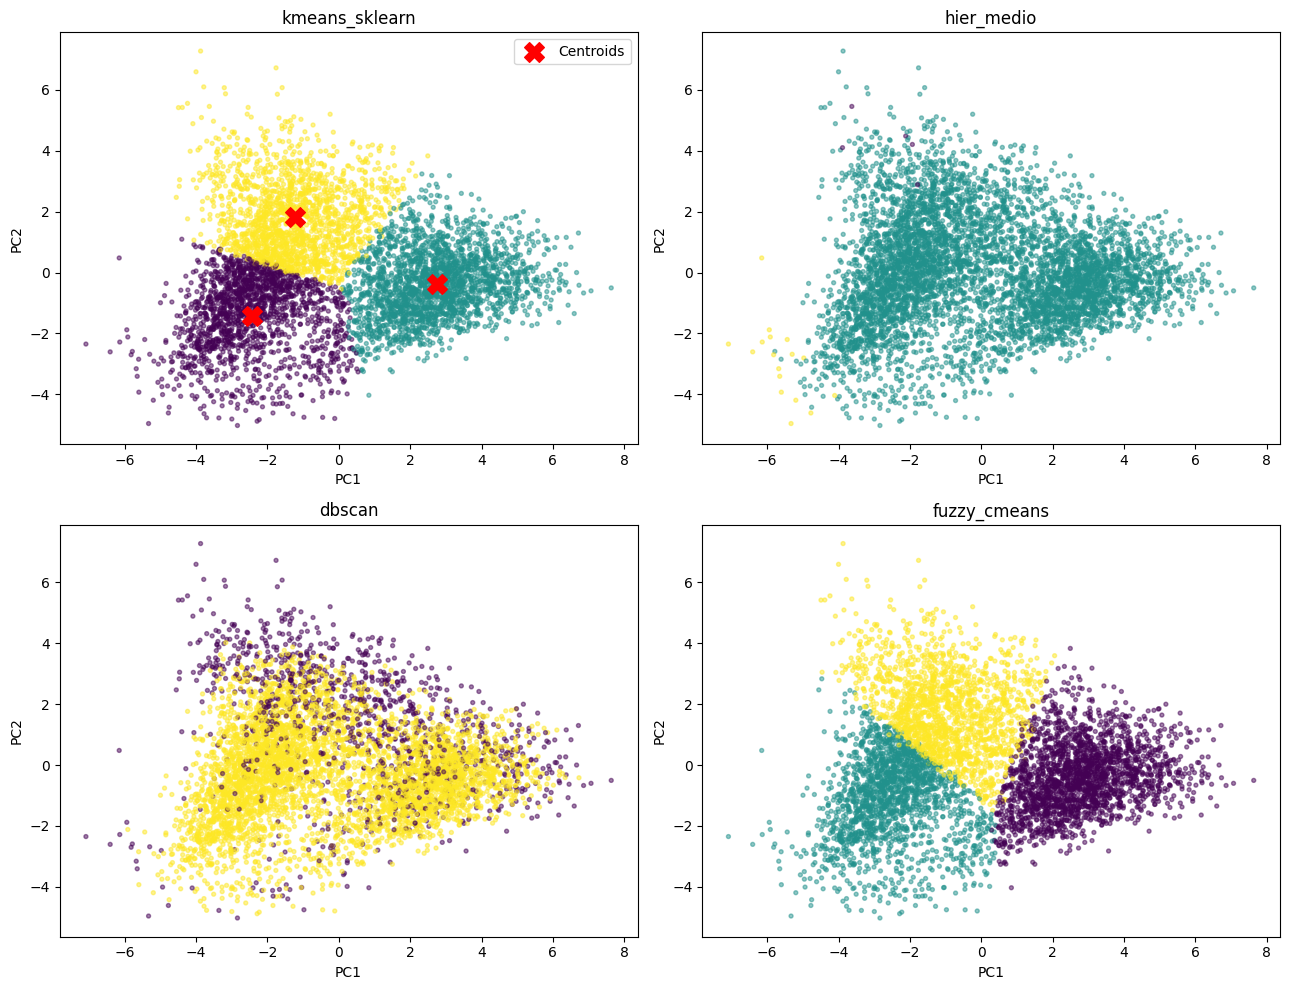

Variância explicada pelos 2 componentes: [0.423 0.189] | total: 0.612


In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_normalized)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, nome in zip(axes.ravel(), ["kmeans_sklearn", "hier_medio", "dbscan", "fuzzy_cmeans"]):
    sc = ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=particoes[nome],
                    cmap="viridis", s=8, alpha=0.5)
    ax.set_title(nome); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

# centroides do k-means projetados
centroids = pca.transform(kmeans.cluster_centers_)
axes[0, 0].scatter(centroids[:, 0], centroids[:, 1], c="red", marker="X", s=200, label="Centroids")
axes[0, 0].legend()
plt.tight_layout(); plt.show()

print("Variância explicada pelos 2 componentes:", pca.explained_variance_ratio_.round(3),
      "| total:", round(pca.explained_variance_ratio_.sum(), 3))

## 11. Perfil dos clusters (K-means)

Média das variáveis por grupo e distribuição regional — é aqui que os grupos ganham interpretação socioeconômica.

In [19]:
df["cluster"] = pred_kmeans

perfil = df.groupby("cluster")[VARIAVEIS].mean().round(2)
perfil["n_municipios"] = df["cluster"].value_counts().sort_index()
perfil

,log_populacao,log_densidade,pct_pop_urbana,idade_mediana,indice_envelhecimento,tx_alfabetizacao_15mais,pct_dom_agua_rede,pct_dom_esgoto_rede,pct_dom_lixo_coletado,renda_dom_pc_2022,pct_pop_ate_meio_sm_2022,log_pib_per_capita,share_vab_agropecuaria,share_vab_adm_publica,tmi_2022_2024,pct_pop_bolsa_familia,n_municipios
cluster,,,,,,,,,,,,,,,,,
0,4.52,1.92,89.72,35.94,63.89,94.41,86.28,69.94,95.54,1547.50,21.80,4.67,11.37,18.87,10.64,17.82,1607
1,4.09,1.28,58.48,32.46,50.55,80.54,63.48,21.36,67.68,748.58,55.57,4.23,19.26,45.83,10.29,51.07,2218
2,3.73,1.09,63.41,38.67,83.95,92.22,68.80,28.83,82.11,1490.75,21.78,4.65,41.30,21.33,9.86,18.93,1745


In [20]:
# distribuição dos clusters por região e validação externa com o IDHM (não usado como input)
print(pd.crosstab(df["cluster"], df["regiao"]))
print()
print("IDHM 2010 médio por cluster (validação externa):")
print(df.groupby("cluster")["idhm_2010"].mean().round(3).sort_values())

regiao    CO    N    NE    S   SE
cluster                          
0        122   32   148  386  919
1         30  325  1627   10  226
2        315   93    19  795  523

IDHM 2010 médio por cluster (validação externa):
cluster
1    0.587
2    0.691
0    0.725
Name: idhm_2010, dtype: float64


In [21]:
# salva o resultado
df[["codigo_ibge", "municipio", "uf", "regiao", "cluster"]].to_csv(
    "municipios_clusterizados.csv", index=False)
print("municipios_clusterizados.csv salvo,", df.shape[0], "municípios rotulados")

municipios_clusterizados.csv salvo, 5570 municípios rotulados


## 12. Experimento: PCA como pré-processamento → k-means

Até aqui a PCA foi usada só para **visualizar**. Agora usamos como **pré-processamento**: retemos os C primeiros componentes (variância acumulada ≥ 85%), clusterizamos sobre eles e comparamos com a partição no espaço original. A PCA decorrelaciona as variáveis — atacando o mesmo problema que a distância de Mahalanobis — e evita que o bloco colinear renda/pobreza/vulnerabilidade "vote várias vezes" na distância Euclidiana.

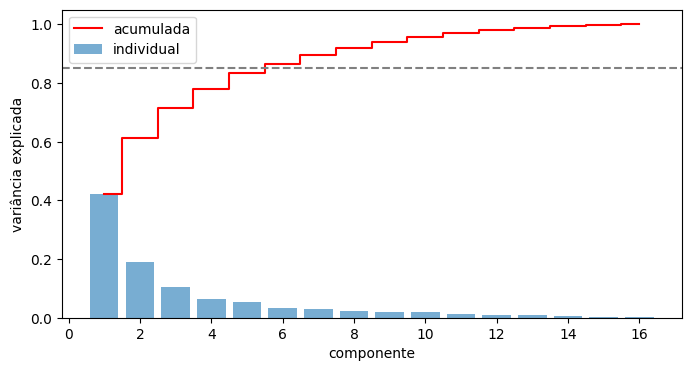

C = 6 componentes explicam 86.7% da variância


In [22]:
pca_full = PCA().fit(X_normalized)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(var_acum) + 1), pca_full.explained_variance_ratio_, alpha=0.6, label="individual")
plt.step(range(1, len(var_acum) + 1), var_acum, where="mid", color="red", label="acumulada")
plt.axhline(0.85, ls="--", color="gray")
plt.xlabel("componente"); plt.ylabel("variância explicada"); plt.legend()
plt.show()

C_COMP = int(np.argmax(var_acum >= 0.85)) + 1
print(f"C = {C_COMP} componentes explicam {100*var_acum[C_COMP-1]:.1f}% da variância")

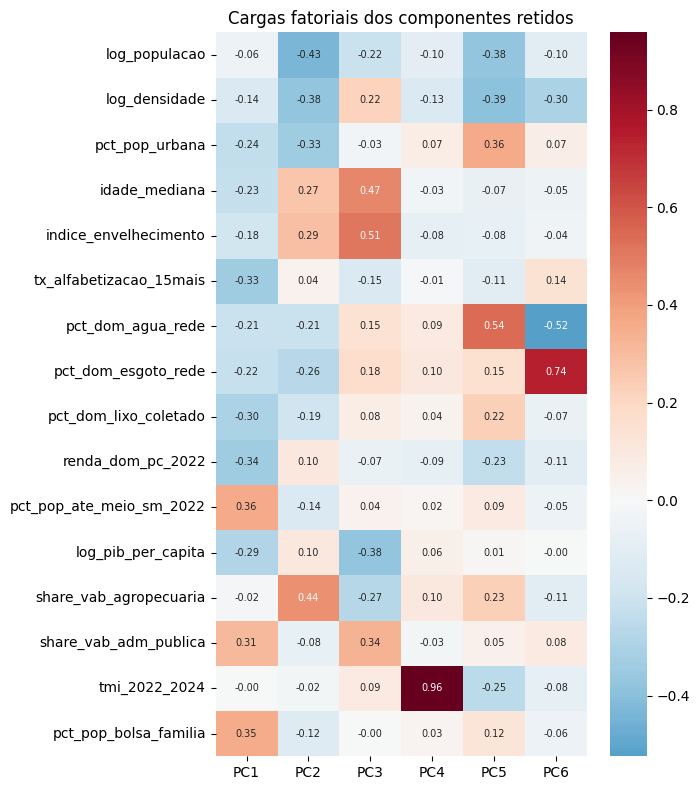

In [23]:
# Cargas fatoriais: como cada variável pesa em cada componente retido
cargas = pd.DataFrame(pca_full.components_[:C_COMP].T,
                      index=VARIAVEIS,
                      columns=[f"PC{i+1}" for i in range(C_COMP)])
plt.figure(figsize=(7, 8))
sns.heatmap(cargas, cmap="RdBu_r", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Cargas fatoriais dos componentes retidos")
plt.tight_layout(); plt.show()

In [24]:
# k-means sobre os componentes retidos, com o mesmo K
X_pca = pca_full.transform(X_normalized)[:, :C_COMP]
kmeans_pca, pred_pca = kmeans_sklearn(X_pca, n)

print("ARI (k-means PCA vs k-means espaço original):",
      round(adjusted_rand_score(pred_pca, pred_kmeans), 3))
print("ARI (k-means PCA vs k-means Mahalanobis):",
      round(adjusted_rand_score(pred_pca, pred_maha), 3))
print()
print("Cruzamento das partições (original x PCA):")
print(pd.crosstab(pred_kmeans, pred_pca, rownames=["original"], colnames=["pca"]))

ARI (k-means PCA vs k-means espaço original): 0.989
ARI (k-means PCA vs k-means Mahalanobis): 0.245

Cruzamento das partições (original x PCA):
pca          0     1     2
original                  
0         1595     1    11
1            2  2215     1
2            1     5  1739


**Como ler:** ARI alto entre as duas versões é um argumento de **robustez** (a estrutura de grupos não depende da redundância entre variáveis); ARI baixo indica que a correlação do bloco socioeconômico dominava o espaço original — e as cargas acima mostram exatamente qual estrutura os componentes capturaram (tipicamente: PC1 = eixo geral de desenvolvimento, PC2 = porte/urbanização, PC3 = estrutura produtiva). Reporte os dois resultados e o ARI na dissertação.

## 13. Validação do número de clusters: silhueta e estabilidade bootstrap

O cotovelo da inércia sugeriu K = 3, mas a inércia sempre decresce com K — precisamos de critérios complementares:
- **Silhueta média**: mede simultaneamente coesão interna e separação entre grupos (quanto maior, melhor);
- **Estabilidade bootstrap**: reamostramos os municípios com reposição, reclusterizamos e medimos (ARI) o quanto a partição se mantém. Um K "verdadeiro" produz partições estáveis; um K artificial oscila entre execuções.

K=2: silhueta média = 0.290
K=3: silhueta média = 0.246
K=4: silhueta média = 0.180
K=5: silhueta média = 0.172
K=6: silhueta média = 0.157
K=7: silhueta média = 0.150
K=8: silhueta média = 0.145


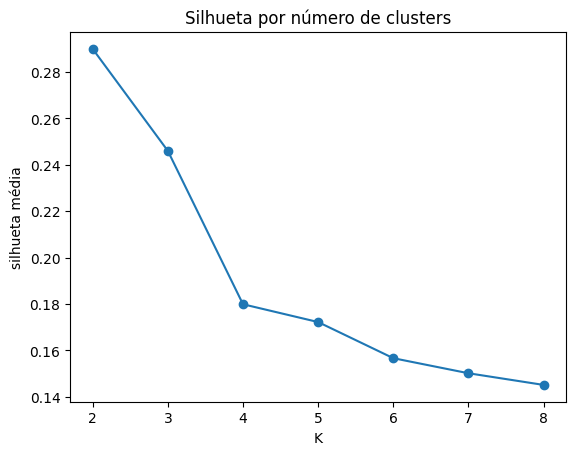

In [25]:
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 9)
silhuetas = []
for k in K_RANGE:
    _, rot = kmeans_sklearn(X_normalized, k)
    silhuetas.append(silhouette_score(X_normalized, rot))
    print(f"K={k}: silhueta média = {silhuetas[-1]:.3f}")

plt.plot(list(K_RANGE), silhuetas, marker="o")
plt.xlabel("K"); plt.ylabel("silhueta média"); plt.title("Silhueta por número de clusters")
plt.show()

Estabilidade bootstrap (ARI médio ± dp, B=20):
  K=2: 0.984 ± 0.008
  K=3: 0.972 ± 0.013
  K=4: 0.856 ± 0.140
  K=5: 0.860 ± 0.107
  K=6: 0.921 ± 0.042
  K=7: 0.866 ± 0.110
  K=8: 0.777 ± 0.095


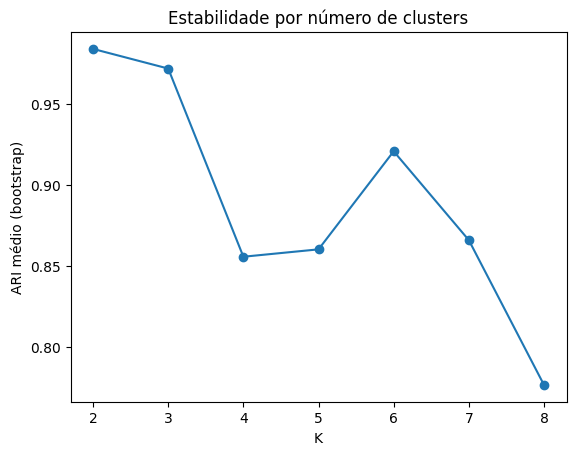

In [26]:
def estabilidade_bootstrap(X, k, B=20, seed=42):
    """Ajusta o k-means em B reamostras bootstrap e mede o ARI da partição
    induzida no conjunto completo contra a partição de referência."""
    rng = np.random.default_rng(seed)
    referencia = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    rot_ref = referencia.labels_
    aris = []
    for b in range(B):
        idx = rng.choice(len(X), len(X), replace=True)
        km_b = KMeans(n_clusters=k, n_init=5, random_state=b).fit(X[idx])
        rot_b = km_b.predict(X)          # partição induzida em TODOS os pontos
        aris.append(adjusted_rand_score(rot_ref, rot_b))
    return np.mean(aris), np.std(aris)

print("Estabilidade bootstrap (ARI médio ± dp, B=20):")
estab = {}
for k in K_RANGE:
    m, s = estabilidade_bootstrap(X_normalized, k)
    estab[k] = m
    print(f"  K={k}: {m:.3f} ± {s:.3f}")

plt.errorbar(list(estab), list(estab.values()), marker="o")
plt.xlabel("K"); plt.ylabel("ARI médio (bootstrap)"); plt.title("Estabilidade por número de clusters")
plt.show()

**Como ler:** o melhor K combina silhueta alta e estabilidade alta. Se K=3 vencer nos dois critérios, o cotovelo fica confirmado por três evidências independentes. Se K=4 ou 5 tiver silhueta próxima e boa estabilidade, vale reportar as duas soluções e examinar qual subdivisão surge (tipicamente o grupo de baixo desenvolvimento se divide em perfis semiárido vs. amazônico).

## 14. Mapas coropléticos com geobr

A malha municipal oficial (IBGE via `geobr`) permite visualizar a dimensão espacial dos clusters — a literatura mostra forte autocorrelação espacial dos perfis socioeconômicos, e o mapa é a evidência mais direta disso.

In [27]:
!pip install -q geobr
import geobr
import os

# baixa a malha (ou reutiliza cópia local, se já baixada)
if os.path.exists("malha_geobr_2020.parquet"):
    import geopandas as gpd
    malha = gpd.read_parquet("malha_geobr_2020.parquet")
else:
    malha = geobr.read_municipality(code_muni="all", year=2020, simplified=True)
    malha.to_parquet("malha_geobr_2020.parquet")

malha["codigo_ibge"] = malha["code_muni"].astype(int).astype(str)
df["codigo_ibge"] = df["codigo_ibge"].astype(str)   # alinhar tipo com a malha
mapa = malha.merge(df[["codigo_ibge", "cluster"]], on="codigo_ibge", how="left")
print(mapa.shape, "| municípios sem cluster:", mapa["cluster"].isna().sum())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 93.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
municipalities_2020_simplified.parquet: 100%|██████████| 20.2M/20.2M [00:00<00:00, 132MB/s] 


(5570, 11) | municípios sem cluster: 0


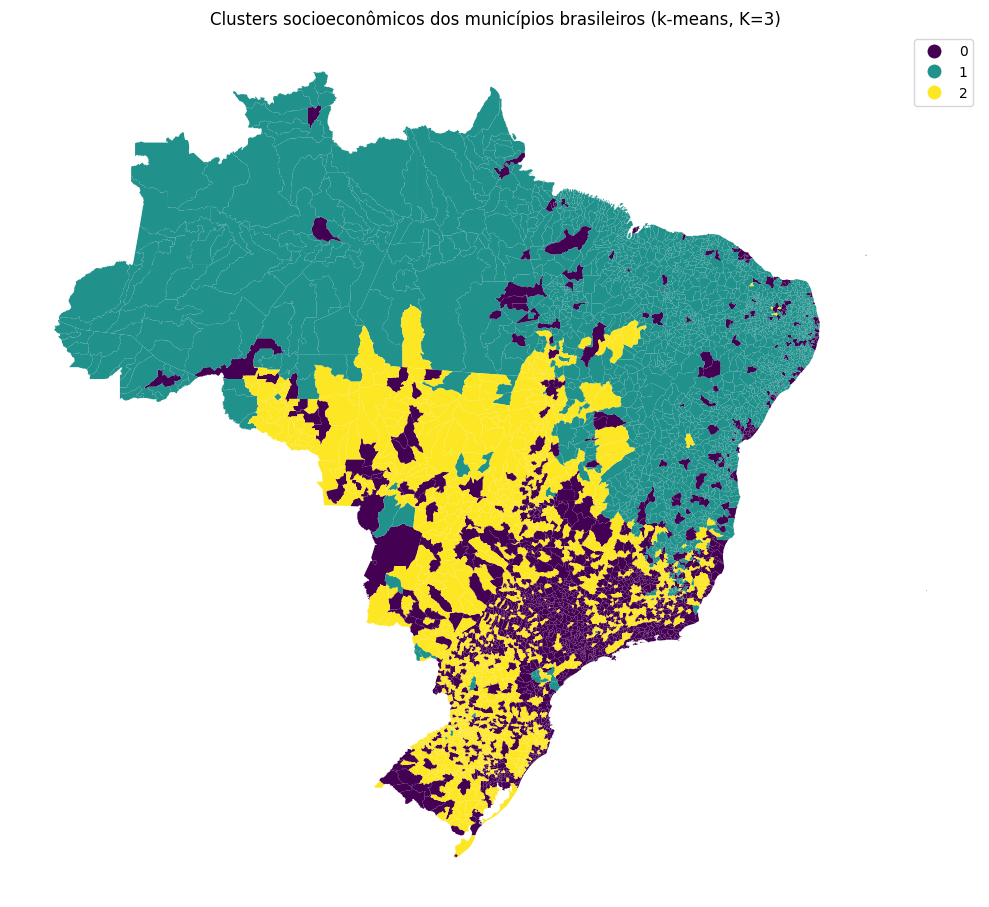

In [28]:
fig, ax = plt.subplots(figsize=(10, 10))
mapa.plot(column="cluster", categorical=True, legend=True, cmap="viridis",
          linewidth=0, ax=ax, missing_kwds={"color": "lightgray", "label": "sem dado"})
ax.set_axis_off()
ax.set_title("Clusters socioeconômicos dos municípios brasileiros (k-means, K=%d)" % n)
plt.tight_layout()
plt.savefig("mapa_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

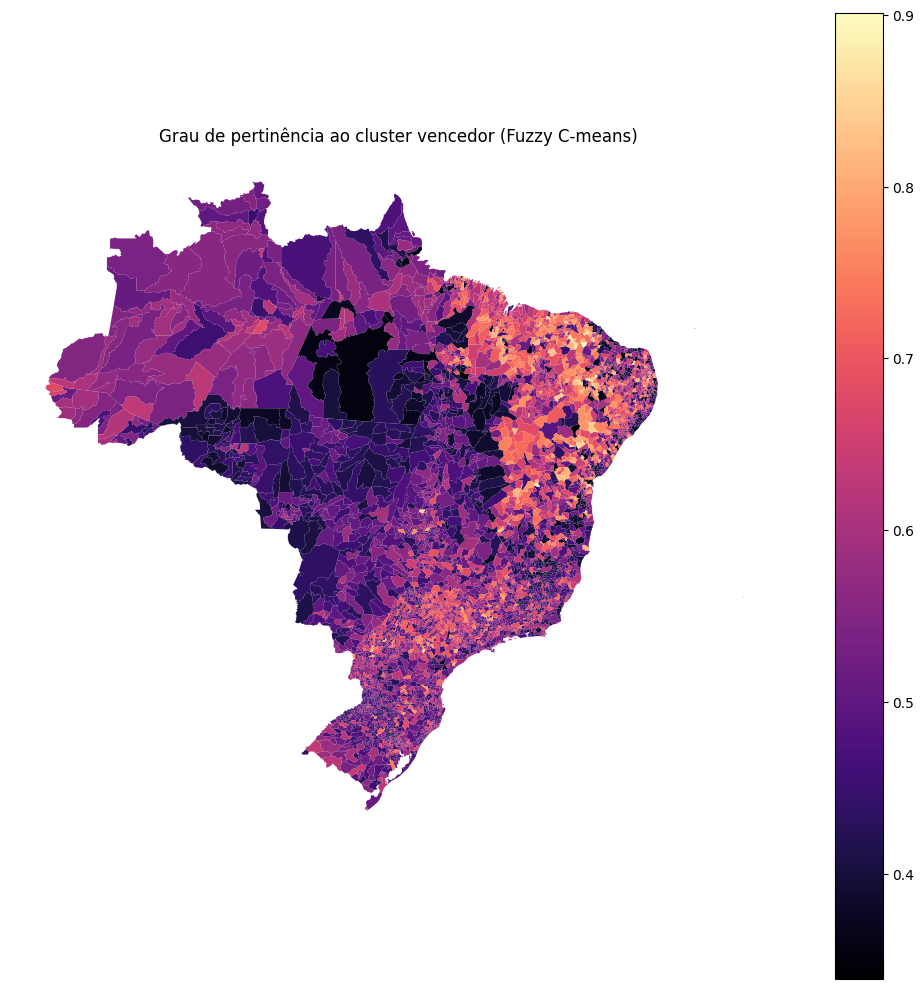

In [29]:
# mapa auxiliar: pertinência máxima do Fuzzy C-means (fronteiras difusas entre perfis)
df["pertinencia_fuzzy"] = pertinencia_max
mapa2 = malha.merge(df[["codigo_ibge", "pertinencia_fuzzy"]], on="codigo_ibge", how="left")

fig, ax = plt.subplots(figsize=(10, 10))
mapa2.plot(column="pertinencia_fuzzy", legend=True, cmap="magma", linewidth=0, ax=ax,
           missing_kwds={"color": "lightgray"})
ax.set_axis_off()
ax.set_title("Grau de pertinência ao cluster vencedor (Fuzzy C-means)")
plt.tight_layout(); plt.show()

## 13. Validação do número de clusters: silhueta e estabilidade bootstrap

O cotovelo da inércia sugeriu K=3, mas a inércia sempre decresce com K — precisamos de critérios que penalizem partições ruins:
- **Silhueta média**: para cada ponto, compara a coesão interna com a separação do cluster vizinho mais próximo (varia de −1 a 1; maior é melhor);
- **Estabilidade bootstrap**: reamostramos os municípios com reposição, reclusterizamos e medimos (ARI) o quanto a partição se mantém. Um K que só aparece "por acaso" produz partições instáveis.

K=2: silhueta média = 0.290
K=3: silhueta média = 0.246
K=4: silhueta média = 0.180
K=5: silhueta média = 0.172
K=6: silhueta média = 0.157
K=7: silhueta média = 0.150
K=8: silhueta média = 0.145


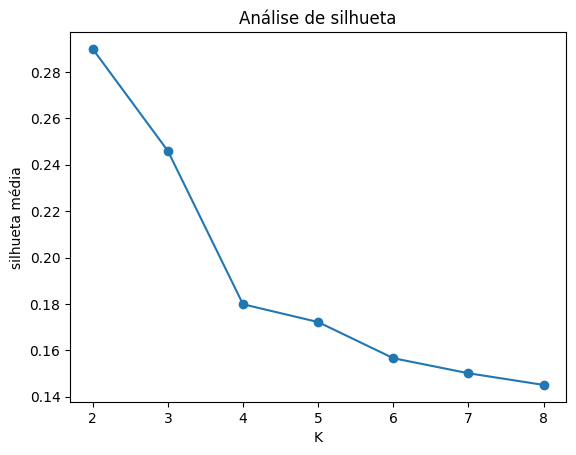

In [30]:
from sklearn.metrics import silhouette_score

sil = {}
for k in range(2, 9):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_normalized)
    sil[k] = silhouette_score(X_normalized, km_k.labels_)
    print(f"K={k}: silhueta média = {sil[k]:.3f}")

plt.plot(list(sil), list(sil.values()), marker="o")
plt.xlabel("K"); plt.ylabel("silhueta média"); plt.title("Análise de silhueta")
plt.show()

In [31]:
def estabilidade_bootstrap(X, k, B=20, seed=42):
    """ARI médio entre a partição de referência e partições em reamostras bootstrap."""
    rng = np.random.default_rng(seed)
    referencia = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)
    aris = []
    for b in range(B):
        idx = rng.choice(len(X), len(X), replace=True)
        km_b = KMeans(n_clusters=k, n_init=5, random_state=b).fit(X[idx])
        rot_b = km_b.predict(X)              # rotula TODOS os pontos com o modelo do bootstrap
        aris.append(adjusted_rand_score(referencia, rot_b))
    return np.mean(aris), np.std(aris)

print("Estabilidade bootstrap (ARI médio ± dp, B=20):")
estab = {}
for k in range(3, 7):
    m, s = estabilidade_bootstrap(X_normalized, k)
    estab[k] = m
    print(f"  K={k}: {m:.3f} ± {s:.3f}")

Estabilidade bootstrap (ARI médio ± dp, B=20):
  K=3: 0.972 ± 0.013
  K=4: 0.856 ± 0.140
  K=5: 0.860 ± 0.107
  K=6: 0.921 ± 0.042


**Como decidir:** o melhor K combina silhueta alta e estabilidade alta. Se K=3 vencer nos dois critérios, a solução tripartite se confirma; se K=4 ou 5 empatar em estabilidade com silhueta próxima, vale examinar o perfil dos clusters extras (tipicamente a separação semiárido vs. Amazônia) e decidir pela **interpretabilidade** — critério legítimo e usual na literatura de tipologias municipais.

## 14. Mapas coropléticos com geobr

A malha municipal oficial (IBGE, via `geobr`) permite visualizar a dimensão espacial dos clusters — o teste qualitativo final: as tipologias da literatura têm forte padrão territorial.

In [32]:
!pip install -q geobr
from geobr import read_municipality

malha = read_municipality(year=2020, simplified=True)
malha["codigo_ibge"] = malha["code_muni"].astype(int).astype(str)
df["codigo_ibge"] = df["codigo_ibge"].astype(str)   # alinhar tipo com a malha
mapa = malha.merge(df[["codigo_ibge", "cluster"]], on="codigo_ibge", how="left")
print(mapa.shape)

(5570, 11)


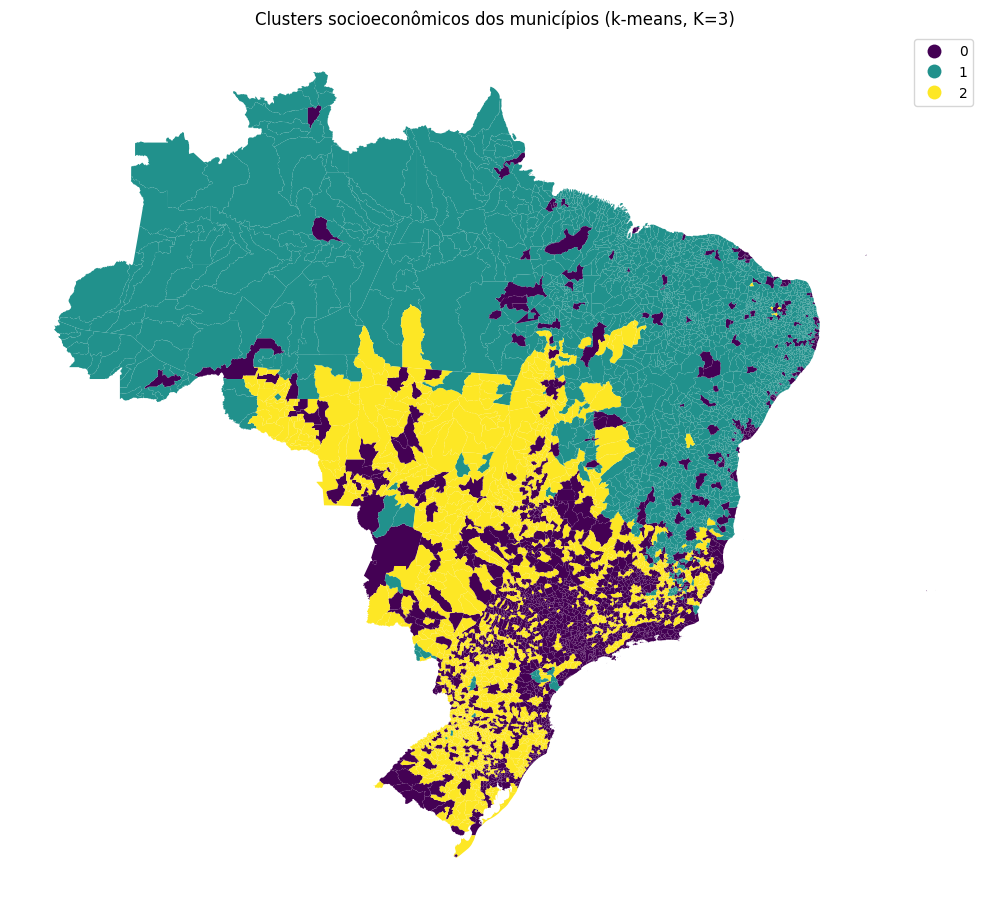

In [33]:
fig, ax = plt.subplots(figsize=(10, 10))
mapa.plot(column="cluster", categorical=True, legend=True, cmap="viridis",
          linewidth=0, ax=ax, missing_kwds={"color": "lightgray", "label": "sem dado"})
ax.set_axis_off()
ax.set_title(f"Clusters socioeconômicos dos municípios (k-means, K={n})")
plt.tight_layout(); plt.show()

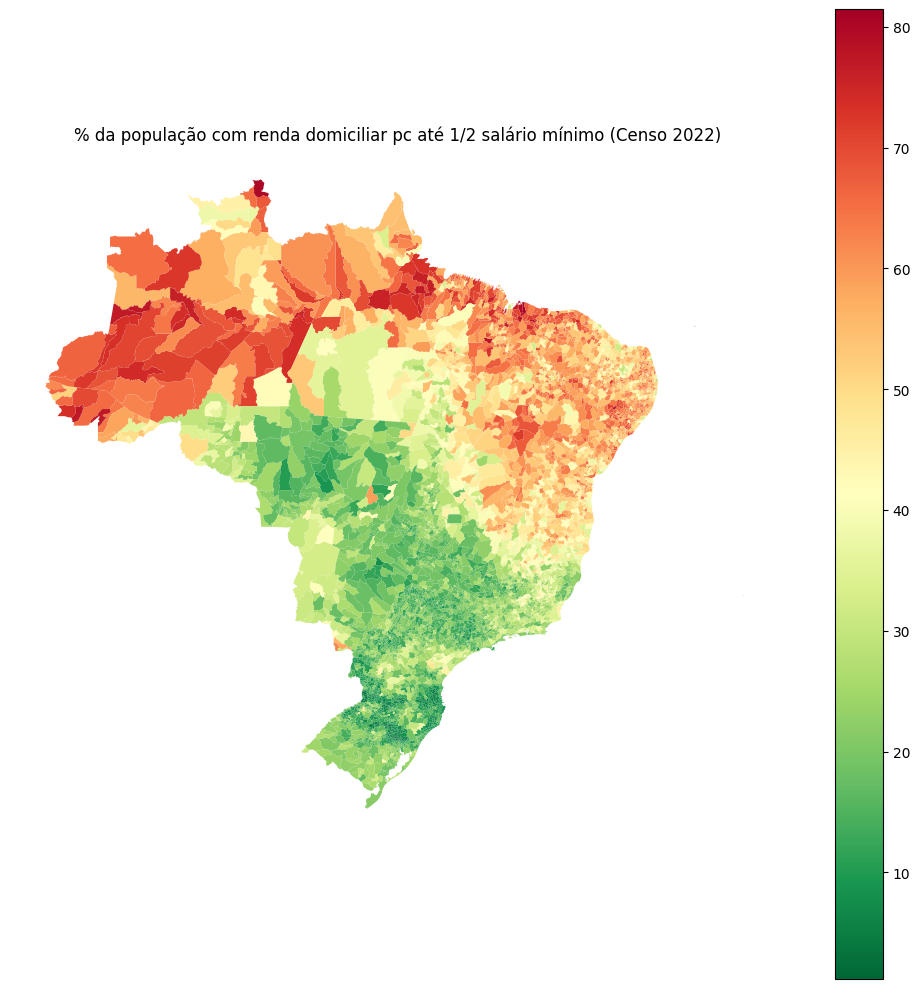

In [34]:
# Mapa complementar: a variável mais discriminante (pobreza monetária 2022)
fig, ax = plt.subplots(figsize=(10, 10))
mapa2 = malha.merge(df[["codigo_ibge", "pct_pop_ate_meio_sm_2022"]], on="codigo_ibge", how="left")
mapa2.plot(column="pct_pop_ate_meio_sm_2022", legend=True, cmap="RdYlGn_r",
           linewidth=0, ax=ax, missing_kwds={"color": "lightgray"})
ax.set_axis_off()
ax.set_title("% da população com renda domiciliar pc até 1/2 salário mínimo (Censo 2022)")
plt.tight_layout(); plt.show()

---
### Síntese e próximos passos
- A inércia/cotovelo sugere o K inicial; confirme com métricas complementares (silhueta, gap statistic) na próxima etapa.
- Compare os perfis: os grupos de baixa renda/saneamento devem concentrar-se no Norte/Nordeste, replicando a literatura.
- O DBSCAN é útil para isolar outliers (metrópoles) antes do k-means final.
- Extensões futuras: estudo de relevância de atributos (VIF, sparse k-means, importância via Random Forest) e autocorrelação espacial dos clusters (I de Moran).